# Optimistix: Nonlinear Solvers in JAX

**Optimistix** is a JAX library for root finding, minimization, least squares, and fixed-point iteration. All solvers are:

- Fully differentiable (gradients through the solve)
- JIT-compilable
- Compatible with vmap for batched problems

## What You'll Learn

1. Root finding (solving f(x) = 0)
2. Fixed-point iteration (solving x = g(x))
3. Minimization (finding argmin f(x))
4. Least squares (fitting models to data)
5. Implicit differentiation
6. Chemical engineering applications

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import optimistix as optx
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"Optimistix version: {optx.__version__}")

W0000 00:00:1767134075.528802 4105100 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767134075.539242 4105100 service.cc:145] XLA service 0x600002654d00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767134075.539252 4105100 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767134075.540241 4105100 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767134075.540250 4105100 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


JAX version: 0.8.1
Optimistix version: 0.0.11


## 1. Root Finding

Find $x$ such that $f(x) = 0$.

### Available Root Finders

| Solver | Method | Best For |
|--------|--------|----------|
| `Newton` | Newton-Raphson | Smooth functions, fast convergence |
| `Chord` | Chord method | When Jacobian is expensive |
| `Bisection` | Bisection | 1D problems, guaranteed convergence |
| `Brent` | Brent's method | 1D problems, no derivatives needed |

In [2]:
# Example: Solve x³ - x - 2 = 0
def f(x, args):
    return x**3 - x - 2

# Newton's method
solver = optx.Newton(rtol=1e-8, atol=1e-8)
x0 = jnp.array(1.5)  # Initial guess

solution = optx.root_find(f, solver, x0)

print(f"Root: x = {float(solution.value):.10f}")
print(f"f(x) = {float(f(solution.value, None)):.2e}")
print(f"Converged: {solution.result == optx.RESULTS.successful}")

Root: x = 1.5213797068
f(x) = 0.00e+00
Converged: True


In [3]:
# Multivariate root finding
def system(xy, args):
    """System of nonlinear equations:
    x² + y² = 4
    x*y = 1
    """
    x, y = xy
    return jnp.array([
        x**2 + y**2 - 4,
        x * y - 1
    ])

solver = optx.Newton(rtol=1e-10, atol=1e-10)
x0 = jnp.array([1.5, 1.0])  # Initial guess

solution = optx.root_find(system, solver, x0)

print(f"Solution: x = {solution.value[0]:.6f}, y = {solution.value[1]:.6f}")
print(f"Residual: {jnp.linalg.norm(system(solution.value, None)):.2e}")

# Verify
x, y = solution.value
print(f"\nVerification:")
print(f"  x² + y² = {x**2 + y**2:.6f} (should be 4)")
print(f"  x * y = {x * y:.6f} (should be 1)")

Solution: x = 1.931852, y = 0.517638
Residual: 1.11e-16

Verification:
  x² + y² = 4.000000 (should be 4)
  x * y = 1.000000 (should be 1)


In [4]:
# Newton for 1D root finding (fast convergence)
def g(x, args):
    return jnp.cos(x) - x  # Find where cos(x) = x

# Newton's method works well for smooth 1D problems
solver = optx.Newton(rtol=1e-10, atol=1e-10)
x0 = jnp.array(0.5)

solution = optx.root_find(g, solver, x0)

print(f"Fixed point of cos: x = {float(solution.value):.10f}")
print(f"cos(x) = {jnp.cos(solution.value):.10f}")

Fixed point of cos: x = 0.7390851332
cos(x) = 0.7390851332


## 2. Fixed-Point Iteration

Find $x$ such that $x = g(x)$.

This is essential for:
- Recycle stream calculations in flowsheets
- Iterative thermodynamic calculations
- Self-consistent field methods

In [5]:
# Example: Find fixed point of cos(x) = x
def g(x, args):
    return jnp.cos(x)

solver = optx.FixedPointIteration(rtol=1e-8, atol=1e-8)
x0 = jnp.array(0.5)

solution = optx.fixed_point(g, solver, x0)

print(f"Fixed point: x = {float(solution.value):.10f}")
print(f"g(x) = cos(x) = {float(jnp.cos(solution.value)):.10f}")
print(f"|x - g(x)| = {abs(solution.value - jnp.cos(solution.value)):.2e}")

Fixed point: x = 0.7390851272
g(x) = cos(x) = 0.7390851372
|x - g(x)| = 9.99e-09


In [6]:
# Chemical Engineering Example: Flash calculation (simplified)
# Find vapor fraction V such that Rachford-Rice equation equals zero

def rachford_rice_residual(V, args):
    """Rachford-Rice equation for flash calculation.
    
    Sum over components: z_i * (K_i - 1) / (1 + V*(K_i - 1)) = 0
    """
    z, K = args  # Feed composition, K-values
    return jnp.sum(z * (K - 1) / (1 + V * (K - 1)))

# Example: 3-component mixture
z = jnp.array([0.3, 0.4, 0.3])  # Feed mole fractions
K = jnp.array([3.0, 1.5, 0.5])  # K-values (vapor/liquid equilibrium ratios)

# Solve for vapor fraction using Newton
solver = optx.Newton(rtol=1e-10, atol=1e-10)
V0 = jnp.array(0.5)

solution = optx.root_find(
    rachford_rice_residual, solver, V0,
    args=(z, K)
)

V = float(solution.value)
print(f"Vapor fraction: V = {V:.6f}")
print(f"Liquid fraction: L = {1-V:.6f}")

# Calculate compositions
x = z / (1 + V * (K - 1))  # Liquid
y = K * x                   # Vapor

print(f"\nLiquid composition: {x}")
print(f"Vapor composition: {y}")
print(f"Sum check - liquid: {jnp.sum(x):.6f}, vapor: {jnp.sum(y):.6f}")

Vapor fraction: V = 1.067639
Liquid fraction: L = -0.067639

Liquid composition: [0.09568527 0.26078684 0.6435279 ]
Vapor composition: [0.2870558  0.39118026 0.32176395]


Sum check - liquid: 1.000000, vapor: 1.000000


## 3. Flowsheet Recycle Example

A classic chemical engineering problem: solving for recycle stream compositions.

In [7]:
# Simple recycle flowsheet:
# Fresh feed + Recycle -> Reactor -> Separator -> Product + Recycle

def flowsheet_iteration(recycle, args):
    """One iteration of the flowsheet.
    
    Args:
        recycle: [F_A_recycle, F_B_recycle] molar flows
        args: (fresh_feed, conversion, split_fraction)
    
    Returns:
        new_recycle: Updated recycle stream
    """
    fresh_feed, X, split = args
    F_A_fresh, F_B_fresh = fresh_feed
    F_A_rec, F_B_rec = recycle
    
    # Mixer: combine fresh feed and recycle
    F_A_in = F_A_fresh + F_A_rec
    F_B_in = F_B_fresh + F_B_rec
    
    # Reactor: A -> B with conversion X
    F_A_out = F_A_in * (1 - X)
    F_B_out = F_B_in + F_A_in * X
    
    # Separator: split into product and recycle
    # (simplified: same split for both components)
    F_A_product = F_A_out * (1 - split)
    F_B_product = F_B_out * (1 - split)
    F_A_recycle_new = F_A_out * split
    F_B_recycle_new = F_B_out * split
    
    return jnp.array([F_A_recycle_new, F_B_recycle_new])

# Parameters
fresh_feed = jnp.array([10.0, 0.0])  # 10 mol/s A, no B
conversion = 0.6   # 60% per-pass conversion
split = 0.8        # 80% recycled
args = (fresh_feed, conversion, split)

# Solve for steady-state recycle
solver = optx.FixedPointIteration(rtol=1e-8, atol=1e-8)
recycle_guess = jnp.array([5.0, 5.0])

solution = optx.fixed_point(flowsheet_iteration, solver, recycle_guess, args=args)

recycle = solution.value
print(f"Converged recycle stream:")
print(f"  A: {recycle[0]:.4f} mol/s")
print(f"  B: {recycle[1]:.4f} mol/s")

# Calculate overall conversion
F_A_in = fresh_feed[0] + recycle[0]
F_A_out = F_A_in * (1 - conversion)
F_A_product = F_A_out * (1 - split)
overall_conversion = 1 - F_A_product / fresh_feed[0]
print(f"\nOverall conversion: {overall_conversion:.1%}")

Converged recycle stream:
  A: 4.7059 mol/s
  B: 35.2941 mol/s

Overall conversion: 88.2%


## 4. Minimization

Find $x$ that minimizes $f(x)$.

### Available Minimizers

| Solver | Method | Best For |
|--------|--------|----------|
| `BFGS` | Quasi-Newton | Smooth unconstrained problems |
| `GradientDescent` | Gradient descent | Simple problems |
| `NonlinearCG` | Conjugate gradient | Large-scale problems |
| `NelderMead` | Simplex | Non-smooth, derivative-free |

In [8]:
# Example: Minimize Rosenbrock function
def rosenbrock(xy, args):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

# BFGS minimizer
solver = optx.BFGS(rtol=1e-8, atol=1e-8)
x0 = jnp.array([-1.0, 1.0])

solution = optx.minimise(rosenbrock, solver, x0)

print(f"Minimum at: ({solution.value[0]:.6f}, {solution.value[1]:.6f})")
print(f"Function value: {rosenbrock(solution.value, None):.2e}")
print(f"Expected: (1.0, 1.0) with f = 0")

Minimum at: (1.000000, 1.000000)
Function value: 0.00e+00
Expected: (1.0, 1.0) with f = 0


In [9]:
# Compare minimizers
minimizers = {
    'BFGS': optx.BFGS(rtol=1e-6, atol=1e-6),
    'GradientDescent': optx.GradientDescent(rtol=1e-6, atol=1e-6, learning_rate=0.001),
    'NonlinearCG': optx.NonlinearCG(rtol=1e-6, atol=1e-6),
}

x0 = jnp.array([0.0, 0.0])

print("Minimizer comparison on Rosenbrock:")
print("-" * 50)
for name, solver in minimizers.items():
    try:
        sol = optx.minimise(rosenbrock, solver, x0, max_steps=10000)
        print(f"{name:20s}: f = {rosenbrock(sol.value, None):.2e}, "
              f"x = ({sol.value[0]:.4f}, {sol.value[1]:.4f})")
    except Exception as e:
        print(f"{name:20s}: Failed - {e}")

Minimizer comparison on Rosenbrock:
--------------------------------------------------


BFGS                : f = 1.60e-18, x = (1.0000, 1.0000)
GradientDescent     : Failed - Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/optimistix/_minimise.py", line 106, in minimise
    return iterative_solve(
           ^^^^^^^^^^^^^^^^
  File "/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/optimistix/_iterate.py", line 349, in iterative_solve
    sol = result.error_if(sol, result != RESULTS.successful)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/equinox/_module/_prebuilt.py", line 33, in __call__
    return self.__func__(self.__self__, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

equinox.EquinoxRuntimeError: The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you

NonlinearCG         : f = 9.50e-10, x = (1.0000, 0.9999)


## 5. Least Squares

Minimize $\sum_i r_i(x)^2$ where $r_i$ are residuals.

### Available Least Squares Solvers

| Solver | Method | Notes |
|--------|--------|-------|
| `LevenbergMarquardt` | LM algorithm | Standard choice |
| `GaussNewton` | Gauss-Newton | Faster near solution |
| `Dogleg` | Trust-region | More robust |

In [10]:
# Fit exponential decay: y = A * exp(-k * t)
# Generate synthetic data
t_data = jnp.linspace(0, 5, 20)
A_true, k_true = 2.5, 0.8
y_true = A_true * jnp.exp(-k_true * t_data)
noise = 0.1 * jax.random.normal(jax.random.PRNGKey(42), t_data.shape)
y_data = y_true + noise

def residuals(params, args):
    """Residuals for least squares fitting."""
    A, k = params
    t, y = args
    y_model = A * jnp.exp(-k * t)
    return y_model - y  # Vector of residuals

# Levenberg-Marquardt
solver = optx.LevenbergMarquardt(rtol=1e-8, atol=1e-8)
params0 = jnp.array([1.0, 0.5])  # Initial guess

solution = optx.least_squares(residuals, solver, params0, args=(t_data, y_data))

A_fit, k_fit = solution.value
print(f"Fitted parameters:")
print(f"  A = {A_fit:.4f} (true: {A_true})")
print(f"  k = {k_fit:.4f} (true: {k_true})")

Fitted parameters:
  A = 2.4444 (true: 2.5)
  k = 0.7945 (true: 0.8)


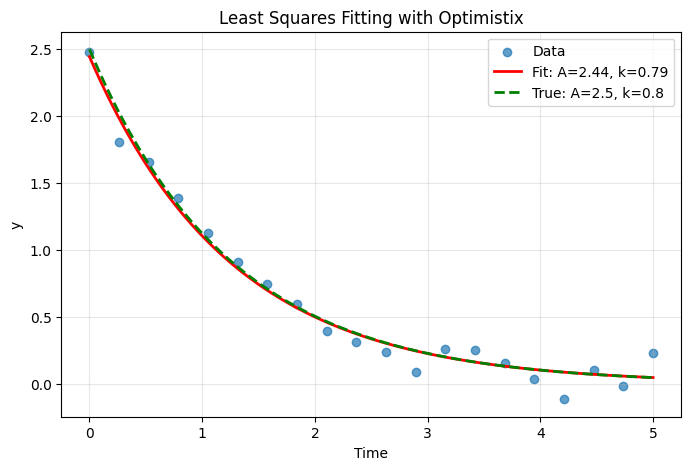

In [11]:
# Plot fit
t_fine = jnp.linspace(0, 5, 100)
y_fit = A_fit * jnp.exp(-k_fit * t_fine)

plt.figure(figsize=(8, 5))
plt.scatter(t_data, y_data, label='Data', alpha=0.7)
plt.plot(t_fine, y_fit, 'r-', label=f'Fit: A={A_fit:.2f}, k={k_fit:.2f}', linewidth=2)
plt.plot(t_fine, A_true * jnp.exp(-k_true * t_fine), 'g--', 
         label=f'True: A={A_true}, k={k_true}', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Least Squares Fitting with Optimistix')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Implicit Differentiation

A key feature of optimistix is **differentiating through the solver**.

Given: $x^* = \text{solve}(f, x_0, \theta)$ where $\theta$ are parameters,

We can compute: $\frac{dx^*}{d\theta}$ using the **implicit function theorem**.

In [12]:
# Example: How does the flash vapor fraction change with K-values?

def flash_calculation(K):
    """Solve flash calculation for given K-values.
    Returns vapor fraction V.
    """
    z = jnp.array([0.3, 0.4, 0.3])  # Fixed feed composition
    
    def residual(V, args):
        return jnp.sum(z * (K - 1) / (1 + V * (K - 1)))
    
    solver = optx.Newton(rtol=1e-10, atol=1e-10)
    V0 = jnp.array(0.5)
    solution = optx.root_find(residual, solver, V0)
    return solution.value

# K-values
K = jnp.array([3.0, 1.5, 0.5])

# Calculate V and its sensitivity to K
V = flash_calculation(K)
dV_dK = jax.jacobian(flash_calculation)(K)

print(f"Vapor fraction: V = {float(V):.6f}")
print(f"\nSensitivity dV/dK:")
for i, (Ki, dVi) in enumerate(zip(K, dV_dK)):
    print(f"  Component {i+1}: K = {Ki:.1f}, dV/dK = {dVi:.4f}")

Vapor fraction: V = 1.067639

Sensitivity dV/dK:
  Component 1: K = 3.0, dV/dK = 0.0599
  Component 2: K = 1.5, dV/dK = 0.3336
  Component 3: K = 0.5, dV/dK = 2.7084


In [13]:
# Verify sensitivity numerically
eps = 1e-6
dV_dK_numerical = []
for i in range(3):
    K_plus = K.at[i].add(eps)
    K_minus = K.at[i].add(-eps)
    dV = (flash_calculation(K_plus) - flash_calculation(K_minus)) / (2 * eps)
    dV_dK_numerical.append(float(dV))

print("Verification (numerical differentiation):")
print(f"  dV/dK (AD):        {dV_dK}")
print(f"  dV/dK (numerical): {jnp.array(dV_dK_numerical)}")

Verification (numerical differentiation):
  dV/dK (AD):        [0.05987755 0.33358499 2.70837418]
  dV/dK (numerical): [0.05987755 0.33358499 2.70837418]


## 7. Chemical Engineering: VLE Calculation

Solve bubble point calculation with Antoine equation.

In [14]:
# Antoine equation for vapor pressure
def antoine_pressure(T, A, B, C):
    """Antoine equation: log10(P) = A - B/(C + T)
    T in °C, P in mmHg
    """
    return 10**(A - B / (C + T))

# Antoine coefficients for benzene and toluene
# (A, B, C) with T in °C, P in mmHg
benzene = (6.90565, 1211.033, 220.790)
toluene = (6.95334, 1343.943, 219.377)

def bubble_point_residual(T, args):
    """Residual for bubble point: sum(y_i) - 1 = sum(x_i * P_i^sat / P) - 1
    """
    x, P_total = args  # Liquid composition, total pressure
    
    # Vapor pressures at temperature T
    P_benz = antoine_pressure(T, *benzene)
    P_tol = antoine_pressure(T, *toluene)
    P_sat = jnp.array([P_benz, P_tol])
    
    # Raoult's law: y_i = x_i * P_i^sat / P
    y = x * P_sat / P_total
    
    return jnp.sum(y) - 1.0

# Bubble point of 50/50 benzene/toluene at 760 mmHg
x = jnp.array([0.5, 0.5])
P_total = 760.0  # mmHg (1 atm)

solver = optx.Newton(rtol=1e-8, atol=1e-8)
T0 = jnp.array(90.0)  # Initial guess in °C

solution = optx.root_find(
    bubble_point_residual, solver, T0,
    args=(x, P_total)
)

T_bubble = float(solution.value)
print(f"Bubble point temperature: {T_bubble:.2f} °C")

# Calculate vapor composition
P_benz = antoine_pressure(T_bubble, *benzene)
P_tol = antoine_pressure(T_bubble, *toluene)
y = x * jnp.array([P_benz, P_tol]) / P_total

print(f"\nVapor composition:")
print(f"  Benzene: {float(y[0]):.4f}")
print(f"  Toluene: {float(y[1]):.4f}")

Bubble point temperature: 92.11 °C

Vapor composition:
  Benzene: 0.7136
  Toluene: 0.2864


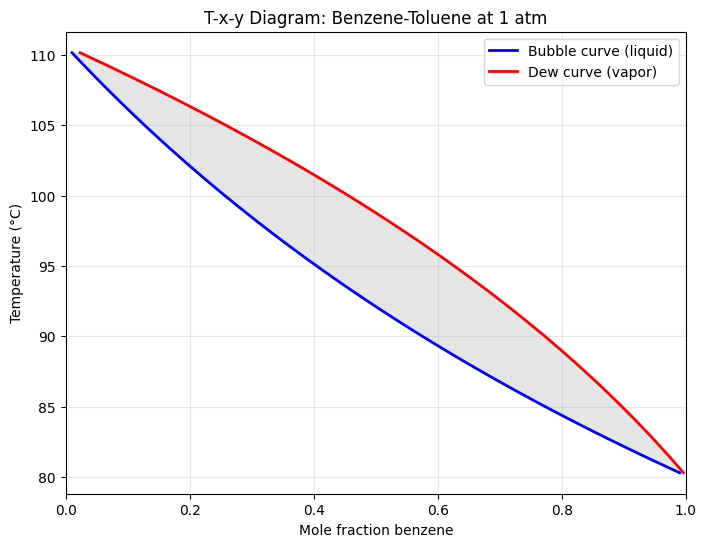

In [15]:
# Generate T-x-y diagram using vmap
def bubble_point(x_benz):
    """Calculate bubble point for given benzene fraction."""
    x = jnp.array([x_benz, 1 - x_benz])
    
    solution = optx.root_find(
        bubble_point_residual, 
        optx.Newton(rtol=1e-8, atol=1e-8),
        jnp.array(90.0),
        args=(x, 760.0)
    )
    
    T = solution.value
    P_benz = antoine_pressure(T, *benzene)
    y_benz = x_benz * P_benz / 760.0
    
    return T, y_benz

# Vectorize over compositions
x_range = jnp.linspace(0.01, 0.99, 50)
T_bubble_curve, y_curve = vmap(bubble_point)(x_range)

# Plot T-x-y diagram
plt.figure(figsize=(8, 6))
plt.plot(x_range, T_bubble_curve, 'b-', label='Bubble curve (liquid)', linewidth=2)
plt.plot(y_curve, T_bubble_curve, 'r-', label='Dew curve (vapor)', linewidth=2)
plt.fill_betweenx(T_bubble_curve, x_range, y_curve, alpha=0.2, color='gray')
plt.xlabel('Mole fraction benzene')
plt.ylabel('Temperature (°C)')
plt.title('T-x-y Diagram: Benzene-Toluene at 1 atm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.show()

## 8. Advanced: Custom Solvers and Options

Optimistix allows fine-grained control over solver behavior.

In [16]:
# Custom Newton solver with damping
def difficult_function(x, args):
    """A function that's hard to solve without damping."""
    return jnp.array([
        x[0]**3 - 3*x[0]*x[1]**2 - 1,
        3*x[0]**2*x[1] - x[1]**3
    ])

# Standard Newton may diverge
# Use chord method or adjust settings
solver = optx.Newton(
    rtol=1e-8, 
    atol=1e-8,
)

x0 = jnp.array([0.5, 0.5])

try:
    solution = optx.root_find(difficult_function, solver, x0, max_steps=100)
    print(f"Solution: {solution.value}")
    print(f"Residual: {jnp.linalg.norm(difficult_function(solution.value, None)):.2e}")
except Exception as e:
    print(f"Solver issue: {e}")

Solution: [-0.5        0.8660254]
Residual: 2.48e-16


In [17]:
# Use throw=False to handle non-convergence gracefully
def risky_solve(x0):
    solver = optx.Newton(rtol=1e-8, atol=1e-8)
    
    solution = optx.root_find(
        difficult_function, 
        solver, 
        x0,
        max_steps=50,
        throw=False  # Don't raise exception on failure
    )
    
    # Check result
    if solution.result == optx.RESULTS.successful:
        return solution.value, True
    else:
        return solution.value, False

# Try different starting points
starts = [jnp.array([0.5, 0.5]), jnp.array([1.0, 0.0]), jnp.array([2.0, 1.0])]

for x0 in starts:
    result, success = risky_solve(x0)
    status = "✓" if success else "✗"
    print(f"Start {x0}: {status} -> {result}")

Start [0.5 0.5]: ✓ -> [-0.5        0.8660254]
Start [1. 0.]: ✓ -> [1. 0.]
Start [2. 1.]: ✓ -> [ 1.00000000e+00 -1.02231372e-17]


## 9. Summary

### Key Optimistix Functions

| Function | Purpose | Signature |
|----------|---------|----------|
| `root_find` | Solve f(x) = 0 | `root_find(fn, solver, y0, args)` |
| `fixed_point` | Solve x = g(x) | `fixed_point(fn, solver, y0, args)` |
| `minimise` | Find argmin f(x) | `minimise(fn, solver, y0, args)` |
| `least_squares` | Minimize ||r(x)||² | `least_squares(fn, solver, y0, args)` |

### Solver Selection Guide

| Problem | Recommended |
|---------|-------------|
| 1D root finding | `Bisection` (robust) or `Brent` |
| Multivariate root finding | `Newton` |
| Fixed-point iteration | `FixedPointIteration` |
| Minimization | `BFGS` |
| Least squares | `LevenbergMarquardt` |

### Key Features

1. **Implicit differentiation**: Gradients through solver automatically
2. **vmap compatible**: Batch problems efficiently
3. **JIT compilable**: Full speed optimization
4. **Composable**: Works with diffrax, optax, equinox

### Related Libraries

- **Lineax**: Linear equation solvers (used internally by implicit methods)
- **Diffrax**: ODE/SDE solvers (previous tutorial)
- **Optax**: Gradient-based optimizers for ML (Tutorial 08)
- **Equinox**: Neural networks in JAX

### Resources

- Documentation: https://docs.kidger.site/optimistix/
- GitHub: https://github.com/patrick-kidger/optimistix